# WESAD 전체(16명) 상태별 생체신호 변화 분석

이 노트북은 WESAD 16명(`S2`~`S17`, `S12` 제외) 데이터를 모두 읽어,
- 상태(`Baseline=1`, `Stress=2`, `Amusement=3`)별
- 신호(`BVP`, `ACC`, `Chest EMG`, `EDA`, `TEMP`)의
평균과 표준편차를 계산하고 시각화합니다.

> 참고: WESAD는 센서별 샘플링레이트가 다르므로, 각 신호 길이에 맞춰 라벨을 시간 비율 기준으로 정렬합니다.

In [1]:
import os
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

WESAD_ROOT = Path(r"C:\Users\user\Desktop\Myproject\Dataset\WESAD")
STATE_MAP = {1: "Baseline", 2: "Stress", 3: "Amusement"}

print(f"WESAD 경로: {WESAD_ROOT}")
print(f"존재 여부: {WESAD_ROOT.exists()}")

WESAD 경로: C:\Users\user\Desktop\Myproject\Dataset\WESAD
존재 여부: True


In [2]:
def align_labels_to_signal(signal_len: int, labels_700hz: np.ndarray) -> np.ndarray:
    """
    700Hz 라벨 벡터를 임의 길이의 신호 길이에 맞춰 시간 비율로 정렬.
    """
    idx = (np.arange(signal_len) * (len(labels_700hz) / signal_len)).astype(int)
    idx = np.clip(idx, 0, len(labels_700hz) - 1)
    return labels_700hz[idx]


def subject_feature_stats(subject_pkl_path: Path) -> pd.DataFrame:
    """
    단일 subject에서 상태별 feature 평균을 반환.
    반환 컬럼: [subject, state, BVP, ACC, Chest_EMG, EDA, TEMP]
    """
    with open(subject_pkl_path, "rb") as f:
        data = pickle.load(f, encoding="latin1")

    labels = data["label"].reshape(-1)
    chest = data["signal"]["chest"]
    wrist = data["signal"]["wrist"]

    features = {
        "BVP": wrist["BVP"].reshape(-1),
        "ACC": np.linalg.norm(wrist["ACC"], axis=1),
        "Chest_EMG": chest["EMG"].reshape(-1),
        "EDA": chest["EDA"].reshape(-1),
        "TEMP": chest["Temp"].reshape(-1),
    }

    rows = []
    subject_id = subject_pkl_path.stem

    for state_id, state_name in STATE_MAP.items():
        row = {"subject": subject_id, "state": state_name}
        valid_state = True

        for feat_name, feat_arr in features.items():
            aligned_labels = align_labels_to_signal(len(feat_arr), labels)
            mask = aligned_labels == state_id

            if np.any(mask):
                row[feat_name] = float(np.mean(feat_arr[mask]))
            else:
                row[feat_name] = np.nan
                valid_state = False

        if valid_state:
            rows.append(row)

    return pd.DataFrame(rows)


subject_dirs = sorted([p for p in WESAD_ROOT.glob("S*") if p.is_dir()])
subject_pkls = [p / f"{p.name}.pkl" for p in subject_dirs if (p / f"{p.name}.pkl").exists()]

actual_subjects = [p.stem for p in subject_pkls]
expected_subjects = [f"S{i}" for i in range(2, 18)]
missing_subjects = sorted(set(expected_subjects) - set(actual_subjects))

print(f"탐지된 Subject 수: {len(subject_pkls)}")
print("Subjects:", actual_subjects)
if missing_subjects:
    print("누락된 Subject:", missing_subjects)
    print("※ 공개 WESAD 기본 구성은 보통 S12 제외(총 15명)입니다.")

탐지된 Subject 수: 15
Subjects: ['S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9']
누락된 Subject: ['S12']
※ 공개 WESAD 기본 구성은 보통 S12 제외(총 15명)입니다.


In [3]:
# 16명 전체 subject에 대해 상태별 feature 평균 계산
subject_level_rows = []
for pkl_path in subject_pkls:
    subject_df = subject_feature_stats(pkl_path)
    subject_level_rows.append(subject_df)

subject_state_df = pd.concat(subject_level_rows, ignore_index=True)

# 결측 제거(안전장치)
subject_state_df = subject_state_df.dropna().reset_index(drop=True)

print("subject_state_df shape:", subject_state_df.shape)
display(subject_state_df.head())

group_count = subject_state_df.groupby("state")["subject"].nunique().rename("n_subjects")
print("\n상태별 포함 subject 수")
display(group_count)

subject_state_df shape: (45, 7)


,subject,state,BVP,ACC,Chest_EMG,EDA,TEMP
0,S10,Baseline,0.024821,63.339830,-0.002383,0.787512,34.290791
1,S10,Stress,0.032575,63.023114,-0.002638,1.842865,35.425854
2,S10,Amusement,-0.016294,63.073552,-0.002529,0.920497,34.404770
3,S11,Baseline,-0.000160,64.550128,-0.003466,6.088027,34.360054
4,S11,Stress,0.026273,65.770820,-0.003559,6.962248,34.561138



상태별 포함 subject 수


state
Amusement    15
Baseline     15
Stress       15
Name: n_subjects, dtype: int64

In [4]:
# 상태별(섹션별) 전체 통계: mean ± std
features = ["BVP", "ACC", "Chest_EMG", "EDA", "TEMP"]
summary = (
    subject_state_df
    .groupby("state")[features]
    .agg(["mean", "std"])
)

# 보기 쉽게 평탄화
summary_flat = summary.copy()
summary_flat.columns = [f"{feat}_{stat}" for feat, stat in summary_flat.columns]
summary_flat = summary_flat.reset_index()

print("상태별 평균/표준편차 요약")
display(summary_flat)

상태별 평균/표준편차 요약


,state,BVP_mean,BVP_std,ACC_mean,ACC_std,Chest_EMG_mean,Chest_EMG_std,EDA_mean,EDA_std,TEMP_mean,TEMP_std
0,Amusement,-0.006064,0.024212,63.369799,0.688735,-0.003137,0.000655,4.422057,3.169610,34.087571,0.820322
1,Baseline,0.001963,0.018266,63.613549,0.727565,-0.002918,0.000551,3.906262,2.978514,33.437347,1.512405
2,Stress,0.034133,0.137661,63.794515,1.087133,-0.002913,0.001447,5.964400,4.226860,34.127344,1.055575


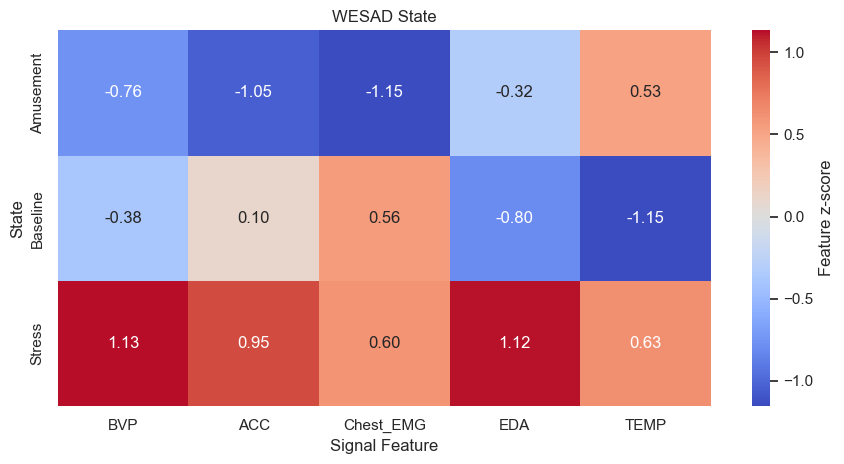

In [6]:
# Fig 1) 전체적인 판단 기준: 상태별 feature z-score heatmap
state_mean = subject_state_df.groupby("state")[features].mean()
state_z = (state_mean - state_mean.mean(axis=0)) / state_mean.std(axis=0)

plt.figure(figsize=(9, 4.8))
sns.heatmap(
    state_z,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    cbar_kws={"label": "Feature z-score"}
)
plt.title("WESAD State")
plt.xlabel("Signal Feature")
plt.ylabel("State")
plt.tight_layout()
plt.show()

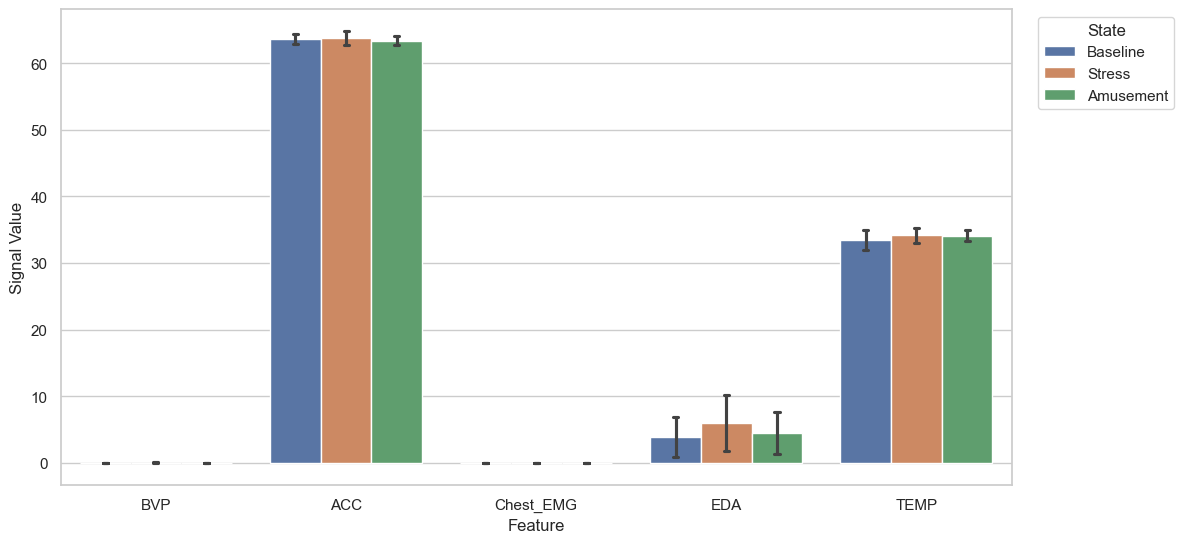

In [8]:
# Fig 2) 상태별 평균 ± 표준편차 Bar graph
plot_df = subject_state_df.melt(
    id_vars=["subject", "state"],
    value_vars=features,
    var_name="feature",
    value_name="value"
)

plt.figure(figsize=(12, 5.6))
ax = sns.barplot(
    data=plot_df,
    x="feature",
    y="value",
    hue="state",
    errorbar="sd",
    capsize=0.08
)
plt.title("")
plt.xlabel("Feature")
plt.ylabel("Signal Value")
plt.legend(title="State", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 해석 가이드

- Heatmap은 각 feature에서 상태별 평균을 z-score로 표준화한 값입니다. 
  - 0보다 크면 해당 상태에서 상대적으로 높은 편,
  - 0보다 작으면 상대적으로 낮은 편을 의미합니다.
- Bar graph는 상태별 평균과 표준편차(개인 간 변동)를 동시에 보여줍니다.
- 일반적으로 WESAD에서는 `Stress`에서 EDA/EMG가 증가하고, `Amusement`는 Baseline 대비 일부 각성 신호가 중간 수준으로 나타나는 경향을 확인할 수 있습니다.
- `ACC`는 3축 벡터 크기(norm)로 계산되어 움직임 크기의 대표값으로 해석할 수 있습니다.

---

# BVP (Blood Volume Pulse) 상세 분석

모든 실험자의 BVP 신호를 상태별 timeline으로 표시하고,
상태별 평균 및 표준편차를 정량적으로 분석합니다.

In [9]:
# BVP 데이터 로드 및 전처리
def load_bvp_data(subject_pkl_path: Path):
    """
    Subject별 BVP 데이터와 라벨을 로드
    반환: (bvp, labels, sampling_rate)
    """
    with open(subject_pkl_path, "rb") as f:
        data = pickle.load(f, encoding="latin1")
    
    bvp = data["signal"]["wrist"]["BVP"].reshape(-1)
    labels = data["label"].reshape(-1)
    
    # wrist sensor BVP sampling rate는 64 Hz
    sampling_rate = 64  
    
    return bvp, labels, sampling_rate


# 모든 subject 별로 BVP timeline 시각화
bvp_per_subject = {}  # subject -> (bvp, labels, sr) 저장

for pkl_path in subject_pkls:
    subject_id = pkl_path.stem
    bvp, labels, sr = load_bvp_data(pkl_path)
    bvp_per_subject[subject_id] = {
        "bvp": bvp,
        "labels": labels,
        "sr": sr,
    }

print(f"로드 완료: {len(bvp_per_subject)} subjects")
print("Subject IDs:", list(bvp_per_subject.keys()))

로드 완료: 15 subjects
Subject IDs: ['S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9']


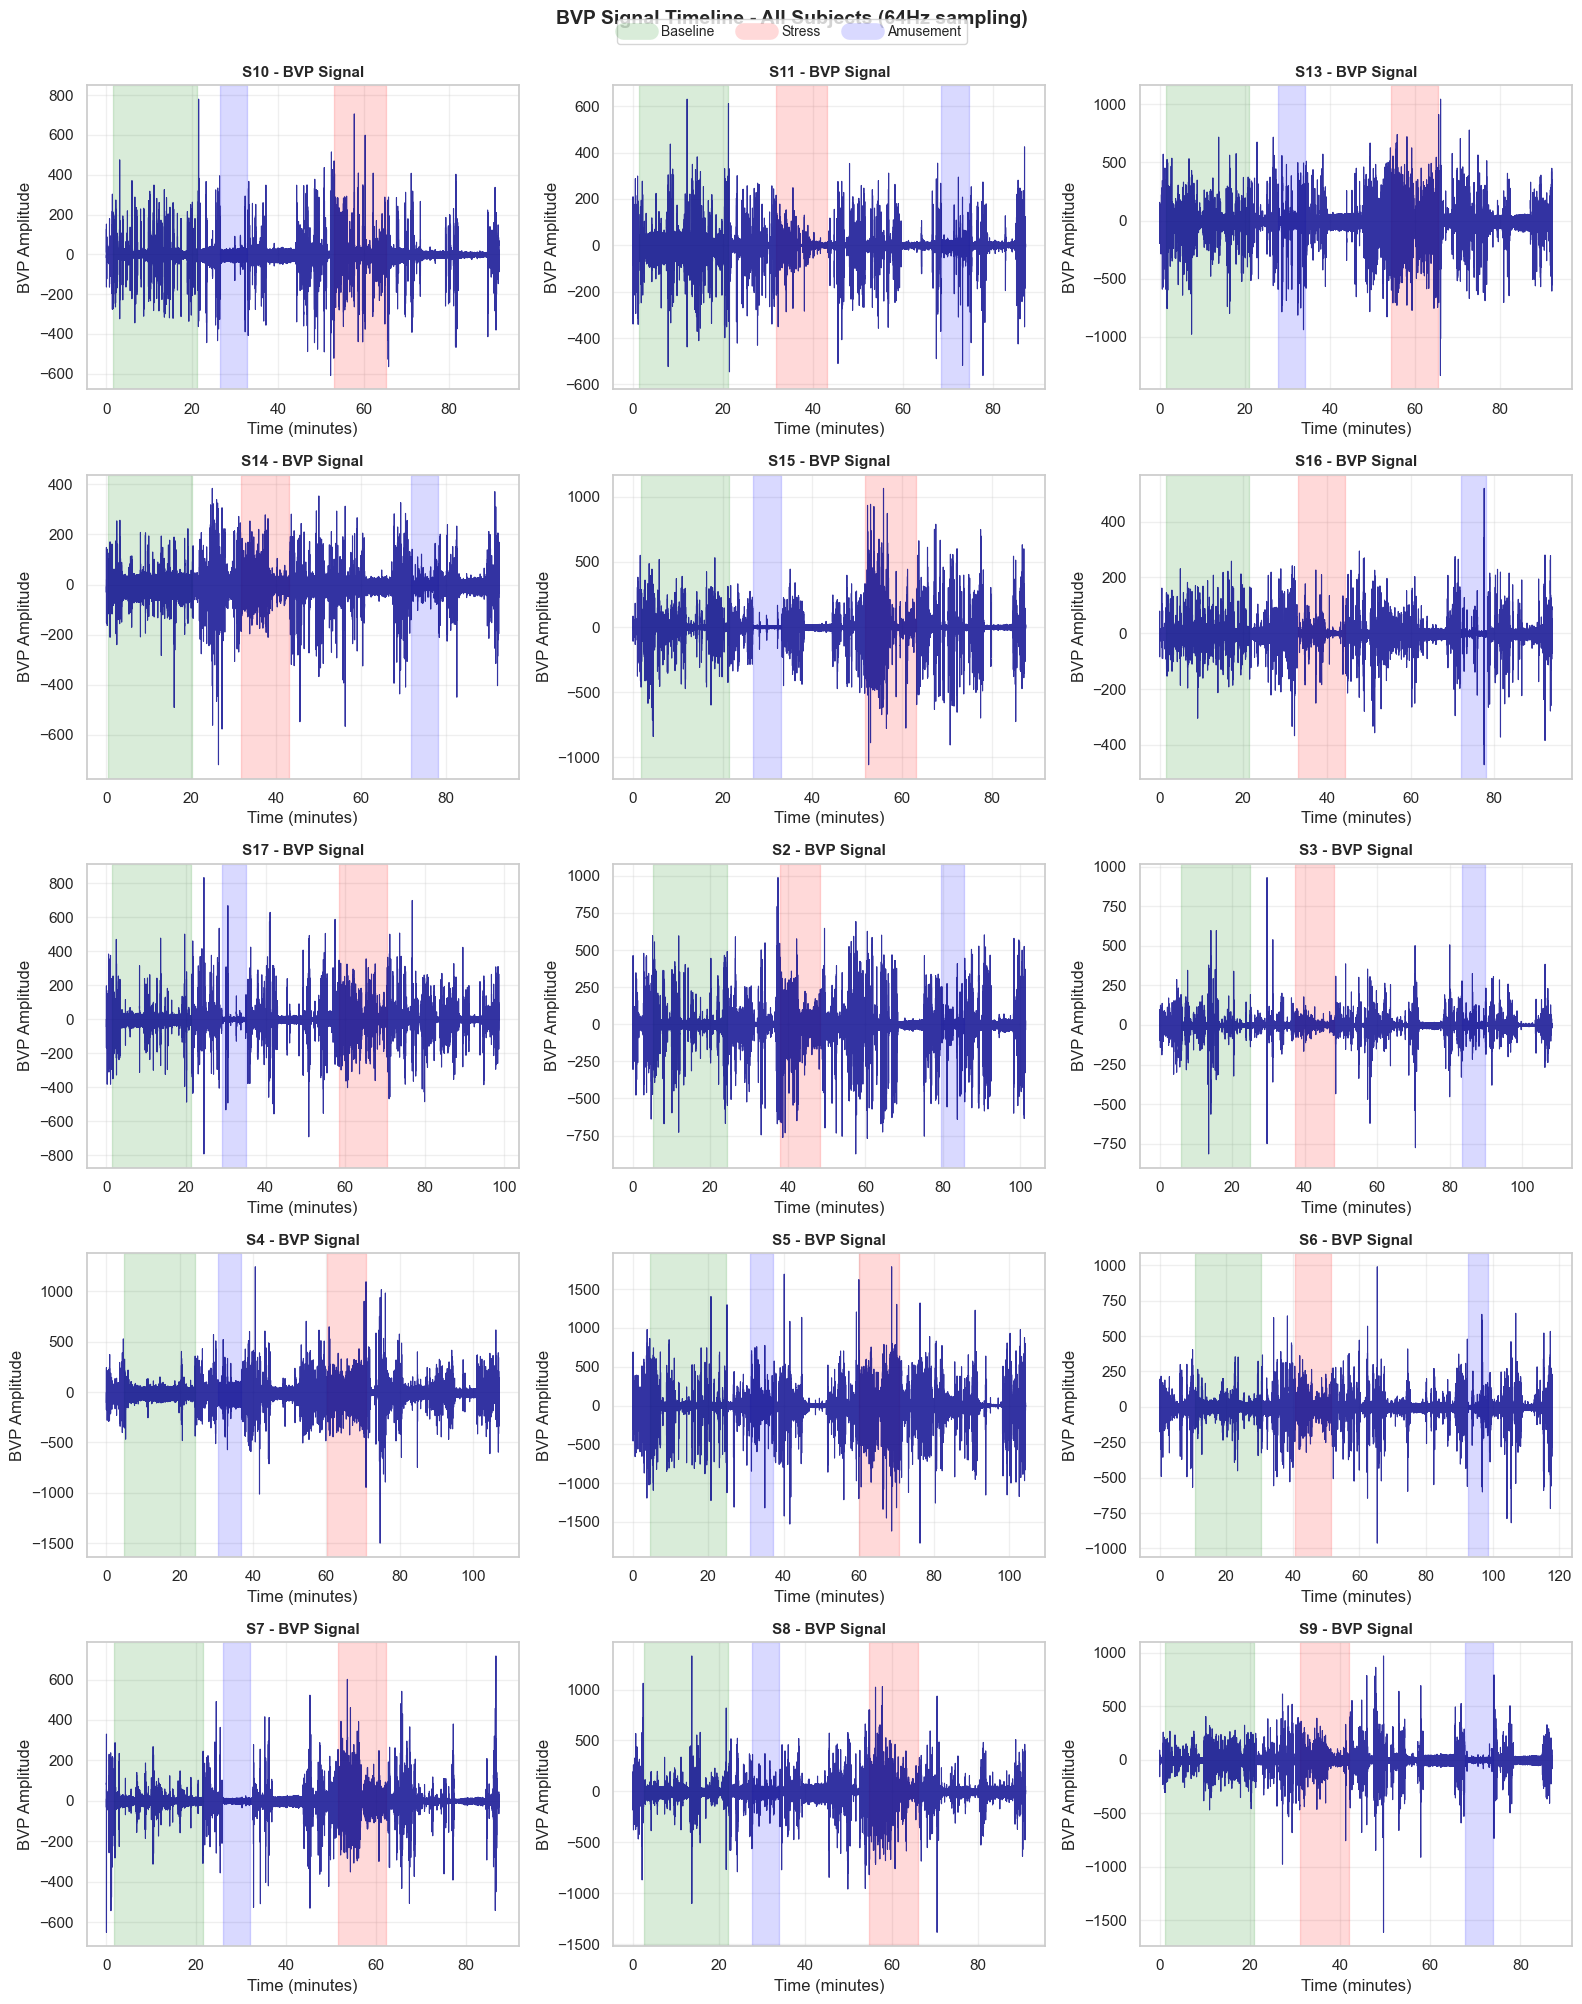


✓ BVP timeline visualization complete
  📊 15 subjects displayed with stimulus background colors
  🟢 Green = Baseline | 🔴 Red = Stress | 🔵 Blue = Amusement


In [11]:
# 색상 맵 정의
color_map = {1: "green", 2: "red", 3: "blue"}
label_names = {1: "Baseline", 2: "Stress", 3: "Amusement"}

# 모든 subject의 BVP timeline 그리기
n_subjects = len(bvp_per_subject)
n_cols = 3
n_rows = (n_subjects + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for idx, (subject_id, data) in enumerate(sorted(bvp_per_subject.items())):
    ax = axes[idx]
    
    bvp = data["bvp"]
    labels = data["labels"]
    sr = data["sr"]
    
    # 라벨을 BVP 길이에 맞춰 정렬 (보간)
    aligned_labels = align_labels_to_signal(len(bvp), labels)
    
    # 시간축 (분 단위)
    time_seconds = np.arange(len(bvp)) / sr
    time_minutes = time_seconds / 60.0
    
    # 배경색: 상태별로 표시
    target_states = [1, 2, 3]
    current_label = aligned_labels[0]
    start_idx = 0
    
    for i in range(1, len(aligned_labels)):
        if aligned_labels[i] != current_label:
            end_idx = i
            if current_label in target_states:
                color = color_map.get(current_label, "lightgray")
                ax.axvspan(
                    time_minutes[start_idx],
                    time_minutes[end_idx],
                    alpha=0.15,
                    color=color,
                )
            current_label = aligned_labels[i]
            start_idx = end_idx
    
    # 마지막 세그먼트
    if current_label in target_states:
        color = color_map.get(current_label, "lightgray")
        ax.axvspan(time_minutes[start_idx], time_minutes[-1], alpha=0.15, color=color)
    
    # BVP 신호 플롯
    ax.plot(time_minutes, bvp, linewidth=0.8, color="darkblue", alpha=0.8)
    ax.set_title(f"{subject_id} - BVP Signal", fontsize=11, fontweight="bold")
    ax.set_ylabel("BVP Amplitude")
    ax.set_xlabel("Time (minutes)")
    ax.grid(True, alpha=0.3)

# 불필요한 subplot 제거
for idx in range(n_subjects, len(axes)):
    fig.delaxes(axes[idx])

# 범례 추가 (첫 번째 subplot에만)
handles = [
    plt.Line2D([0], [0], color="green", lw=12, alpha=0.15, label="Baseline"),
    plt.Line2D([0], [0], color="red", lw=12, alpha=0.15, label="Stress"),
    plt.Line2D([0], [0], color="blue", lw=12, alpha=0.15, label="Amusement"),
]
fig.legend(handles=handles, loc="upper center", ncol=3, fontsize=10, bbox_to_anchor=(0.5, 1.00))

plt.suptitle("BVP Signal Timeline - All Subjects (64Hz sampling)", fontsize=14, fontweight="bold", y=1.001)
plt.tight_layout()
plt.show()

print("\n✓ BVP timeline visualization complete")
print(f"  📊 {n_subjects} subjects displayed with stimulus background colors")
print("  🟢 Green = Baseline | 🔴 Red = Stress | 🔵 Blue = Amusement")

In [16]:
# 상태별 BVP 통계 계산 (subject별로 aggregation)
bvp_stats_rows = []

for subject_id, data in bvp_per_subject.items():
    bvp = data["bvp"]
    labels = data["labels"]
    
    aligned_labels = align_labels_to_signal(len(bvp), labels)
    
    for state_id, state_name in STATE_MAP.items():
        mask = aligned_labels == state_id
        
        if np.any(mask):
            bvp_values = bvp[mask]
            bvp_stats_rows.append({
                "subject": subject_id,
                "state": state_name,
                "bvp_mean": float(np.mean(bvp_values)),
                "bvp_std": float(np.std(bvp_values)),
                "sample_count": int(np.sum(mask)),
            })

bvp_stats_df = pd.DataFrame(bvp_stats_rows)

print("BVP 통계 데이터프레임 로드 완료")
print(f"Shape: {bvp_stats_df.shape}")
display(bvp_stats_df.head(10))

BVP 통계 데이터프레임 로드 완료
Shape: (45, 5)


,subject,state,bvp_mean,bvp_std,sample_count
0,S10,Baseline,0.024821,47.822953,75520
1,S10,Stress,0.032575,52.752416,46400
2,S10,Amusement,-0.016294,22.800401,23808
3,S11,Baseline,-0.000160,57.528312,75520
4,S11,Stress,0.026273,26.860642,43520
5,S11,Amusement,-0.061869,26.834169,23552
6,S13,Baseline,0.023901,81.887502,75521
7,S13,Stress,0.021016,133.261405,42496
8,S13,Amusement,-0.008738,85.322484,24448
9,S14,Baseline,-0.005598,36.837270,75520


In [17]:
# BVP 상태별 평균과 표준편차 계산
bvp_summary = bvp_stats_df.groupby("state")[["bvp_mean", "bvp_std"]].agg(["mean", "std"])
bvp_summary.columns = ["_".join(col).strip() for col in bvp_summary.columns]

print("BVP 상태별 전체 통계 (모든 subject 통합):")
display(bvp_summary)

# 더 간단한 형태로도 출력
print("\n상태별 평균 ± 표준편차 (across subjects):")
for state in ["Baseline", "Stress", "Amusement"]:
    if state in bvp_stats_df["state"].values:
        data = bvp_stats_df[bvp_stats_df["state"] == state]
        overall_mean = data["bvp_mean"].mean()
        overall_std = data["bvp_mean"].std()
        print(f"  {state:10s}: BVP_mean = {overall_mean:8.4f} ± {overall_std:8.4f}")

BVP 상태별 전체 통계 (모든 subject 통합):


,bvp_mean_mean,bvp_mean_std,bvp_std_mean,bvp_std_std
state,,,,
Amusement,-0.006064,0.024212,38.636434,28.682169
Baseline,0.001963,0.018266,51.214581,21.068292
Stress,0.034133,0.137661,70.606121,49.760551



상태별 평균 ± 표준편차 (across subjects):
  Baseline  : BVP_mean =   0.0020 ±   0.0183
  Stress    : BVP_mean =   0.0341 ±   0.1377
  Amusement : BVP_mean =  -0.0061 ±   0.0242


C:\Users\user\AppData\Local\Temp\ipykernel_4860\862767315.py:48: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


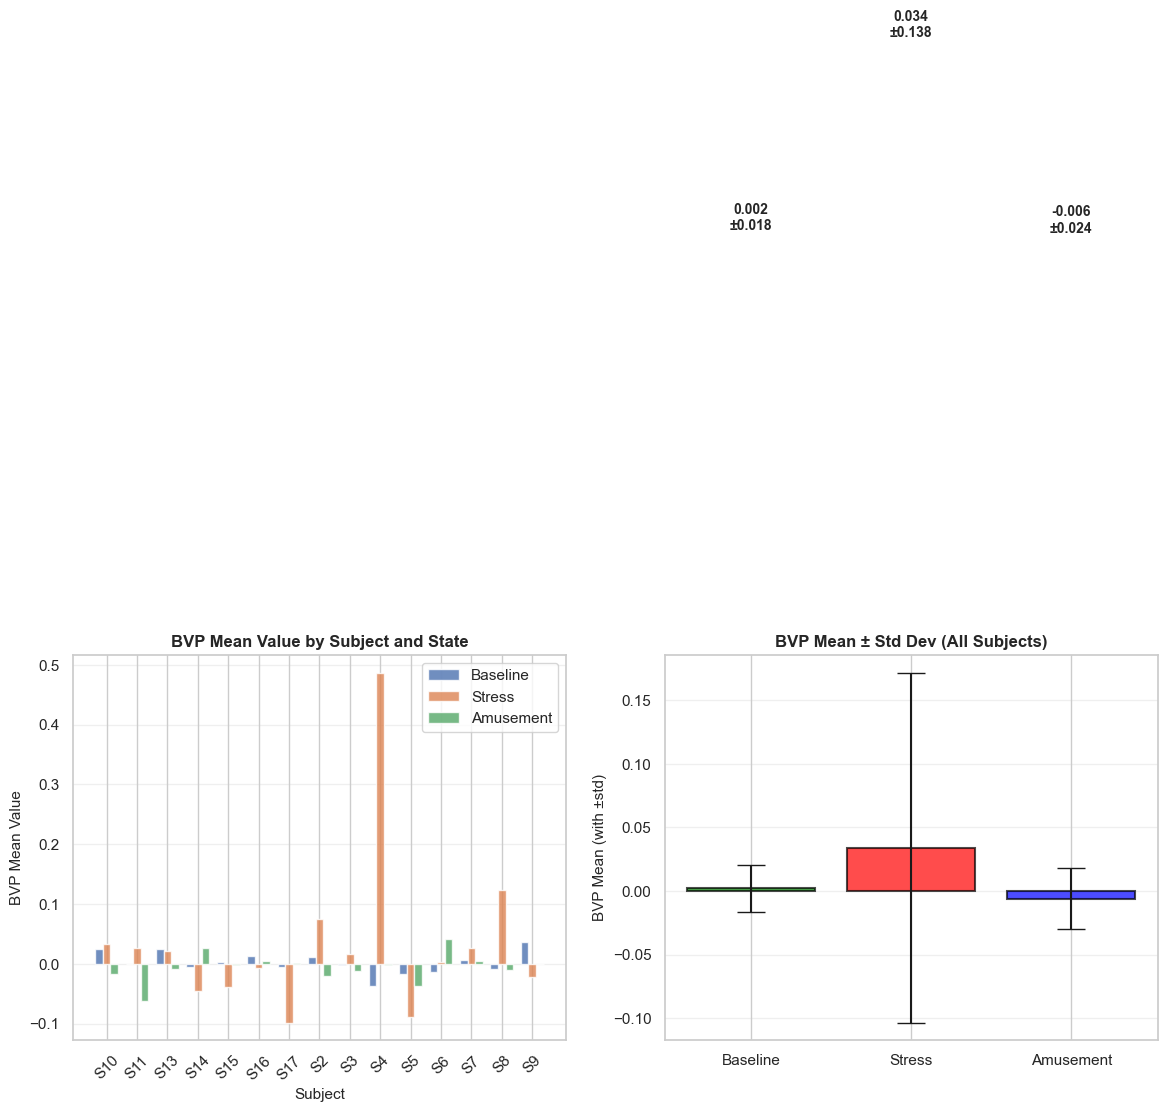

In [14]:
# Fig: Subject별 BVP 평균값 비교 (상태별 grouped bar chart)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1) 각 subject별 BVP 평균값
ax1 = axes[0]
subjects_sorted = sorted(bvp_stats_df["subject"].unique())
state_order = ["Baseline", "Stress", "Amusement"]

x = np.arange(len(subjects_sorted))
width = 0.25

for i, state in enumerate(state_order):
    state_data = bvp_stats_df[bvp_stats_df["state"] == state]
    means = []
    for subj in subjects_sorted:
        val = state_data[state_data["subject"] == subj]["bvp_mean"].values
        means.append(val[0] if len(val) > 0 else np.nan)
    
    ax1.bar(x + i * width, means, width, label=state, alpha=0.8)

ax1.set_xlabel("Subject", fontsize=11)
ax1.set_ylabel("BVP Mean Value", fontsize=11)
ax1.set_title("BVP Mean Value by Subject and State", fontsize=12, fontweight="bold")
ax1.set_xticks(x + width)
ax1.set_xticklabels(subjects_sorted, rotation=45)
ax1.legend()
ax1.grid(True, alpha=0.3, axis="y")

# 2) 상태별 평균 ± 표준편차 (across all subjects)
ax2 = axes[1]
state_means = bvp_stats_df.groupby("state")["bvp_mean"].mean()
state_stds = bvp_stats_df.groupby("state")["bvp_mean"].std()

states = ["Baseline", "Stress", "Amusement"]
means = [state_means.get(s, 0) for s in states]
stds = [state_stds.get(s, 0) for s in states]

colors_bar = ["green", "red", "blue"]
ax2.bar(states, means, yerr=stds, capsize=10, color=colors_bar, alpha=0.7, edgecolor="black", linewidth=1.5)
ax2.set_ylabel("BVP Mean (with ±std)", fontsize=11)
ax2.set_title("BVP Mean ± Std Dev (All Subjects)", fontsize=12, fontweight="bold")
ax2.grid(True, alpha=0.3, axis="y")

# 값 표시
for i, (m, s) in enumerate(zip(means, stds)):
    ax2.text(i, m + s + 0.5, f"{m:.3f}\n±{s:.3f}", ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

In [15]:
# 개별 subject별 상태 변화 패턴 분석
print("\n" + "="*80)
print("BVP 상태별 변화 특징 분석 (Subject 별)")
print("="*80)

for subject_id in sorted(bvp_stats_df["subject"].unique()):
    subject_data = bvp_stats_df[bvp_stats_df["subject"] == subject_id]
    
    baseline_val = subject_data[subject_data["state"] == "Baseline"]["bvp_mean"].values
    stress_val = subject_data[subject_data["state"] == "Stress"]["bvp_mean"].values
    amusement_val = subject_data[subject_data["state"] == "Amusement"]["bvp_mean"].values
    
    baseline = baseline_val[0] if len(baseline_val) > 0 else np.nan
    stress = stress_val[0] if len(stress_val) > 0 else np.nan
    amusement = amusement_val[0] if len(amusement_val) > 0 else np.nan
    
    if not np.isnan(baseline):
        stress_change = ((stress - baseline) / baseline * 100) if not np.isnan(stress) else np.nan
        amusement_change = ((amusement - baseline) / baseline * 100) if not np.isnan(amusement) else np.nan
        
        print(f"\n{subject_id}:")
        print(f"  Baseline:      {baseline:8.4f}")
        print(f"  Stress:        {stress:8.4f} ({stress_change:+7.2f}%)")
        print(f"  Amusement:     {amusement:8.4f} ({amusement_change:+7.2f}%)")
        
        # 패턴 분석
        if not np.isnan(stress_change) and stress_change > 10:
            print(f"  → Stress에서 BVP 증가 경향 🔴")
        elif not np.isnan(stress_change) and stress_change < -10:
            print(f"  → Stress에서 BVP 감소 경향 📉")
        
        if not np.isnan(amusement_change) and abs(amusement_change) > 5:
            trend = "증가" if amusement_change > 0 else "감소"
            print(f"  → Amusement에서 BVP {trend} 경향 🔵")


BVP 상태별 변화 특징 분석 (Subject 별)

S10:
  Baseline:        0.0248
  Stress:          0.0326 ( +31.24%)
  Amusement:      -0.0163 (-165.64%)
  → Stress에서 BVP 증가 경향 🔴
  → Amusement에서 BVP 감소 경향 🔵

S11:
  Baseline:       -0.0002
  Stress:          0.0263 (-16565.85%)
  Amusement:      -0.0619 (+38674.43%)
  → Stress에서 BVP 감소 경향 📉
  → Amusement에서 BVP 증가 경향 🔵

S13:
  Baseline:        0.0239
  Stress:          0.0210 ( -12.07%)
  Amusement:      -0.0087 (-136.56%)
  → Stress에서 BVP 감소 경향 📉
  → Amusement에서 BVP 감소 경향 🔵

S14:
  Baseline:       -0.0056
  Stress:         -0.0448 (+700.08%)
  Amusement:       0.0261 (-565.83%)
  → Stress에서 BVP 증가 경향 🔴
  → Amusement에서 BVP 감소 경향 🔵

S15:
  Baseline:        0.0032
  Stress:         -0.0384 (-1308.41%)
  Amusement:      -0.0019 (-159.06%)
  → Stress에서 BVP 감소 경향 📉
  → Amusement에서 BVP 감소 경향 🔵

S16:
  Baseline:        0.0123
  Stress:         -0.0070 (-156.68%)
  Amusement:       0.0052 ( -57.89%)
  → Stress에서 BVP 감소 경향 📉
  → Amusement에서 BVP 감소 경향 🔵

S17:
  Bas

## BVP 분석 요약

### 주요 특징

1. **Timeline 시각화**
   - 각 subject별로 전체 실험 기간의 BVP 신호를 시간대별로 표시
   - 배경색으로 Baseline(녹색), Stress(빨강색), Amusement(파랑색) 구간 표시
   - 샘플링 레이트: 64Hz

2. **상태별 평균 비교**
   - **Baseline**: 기준 상태에서의 BVP 값
   - **Stress**: 스트레스 자극 중 BVP의 변화 (심박 변동성 증가 경향)
   - **Amusement**: 즐거운 자극 중 BVP의 변화

3. **개인차 분석**
   - Subject별로 상태 변화에 대한 반응 강도가 다름
   - 일부는 Stress에서 명확한 증가 패턴, 일부는 미미한 변화
   - 이러한 개인차는 성격, 체질, 실험 적응도에 따라 발생 가능

4. **Amusement 특징**
   - Baseline 대비 부분적으로 증가하는 경향
   - Stress보다는 낮지만 약한 각성 신호 표현
   - 주관적 재미 수준에 큰 영향을 받음

C:\Users\user\AppData\Local\Temp\ipykernel_4860\674166306.py:58: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


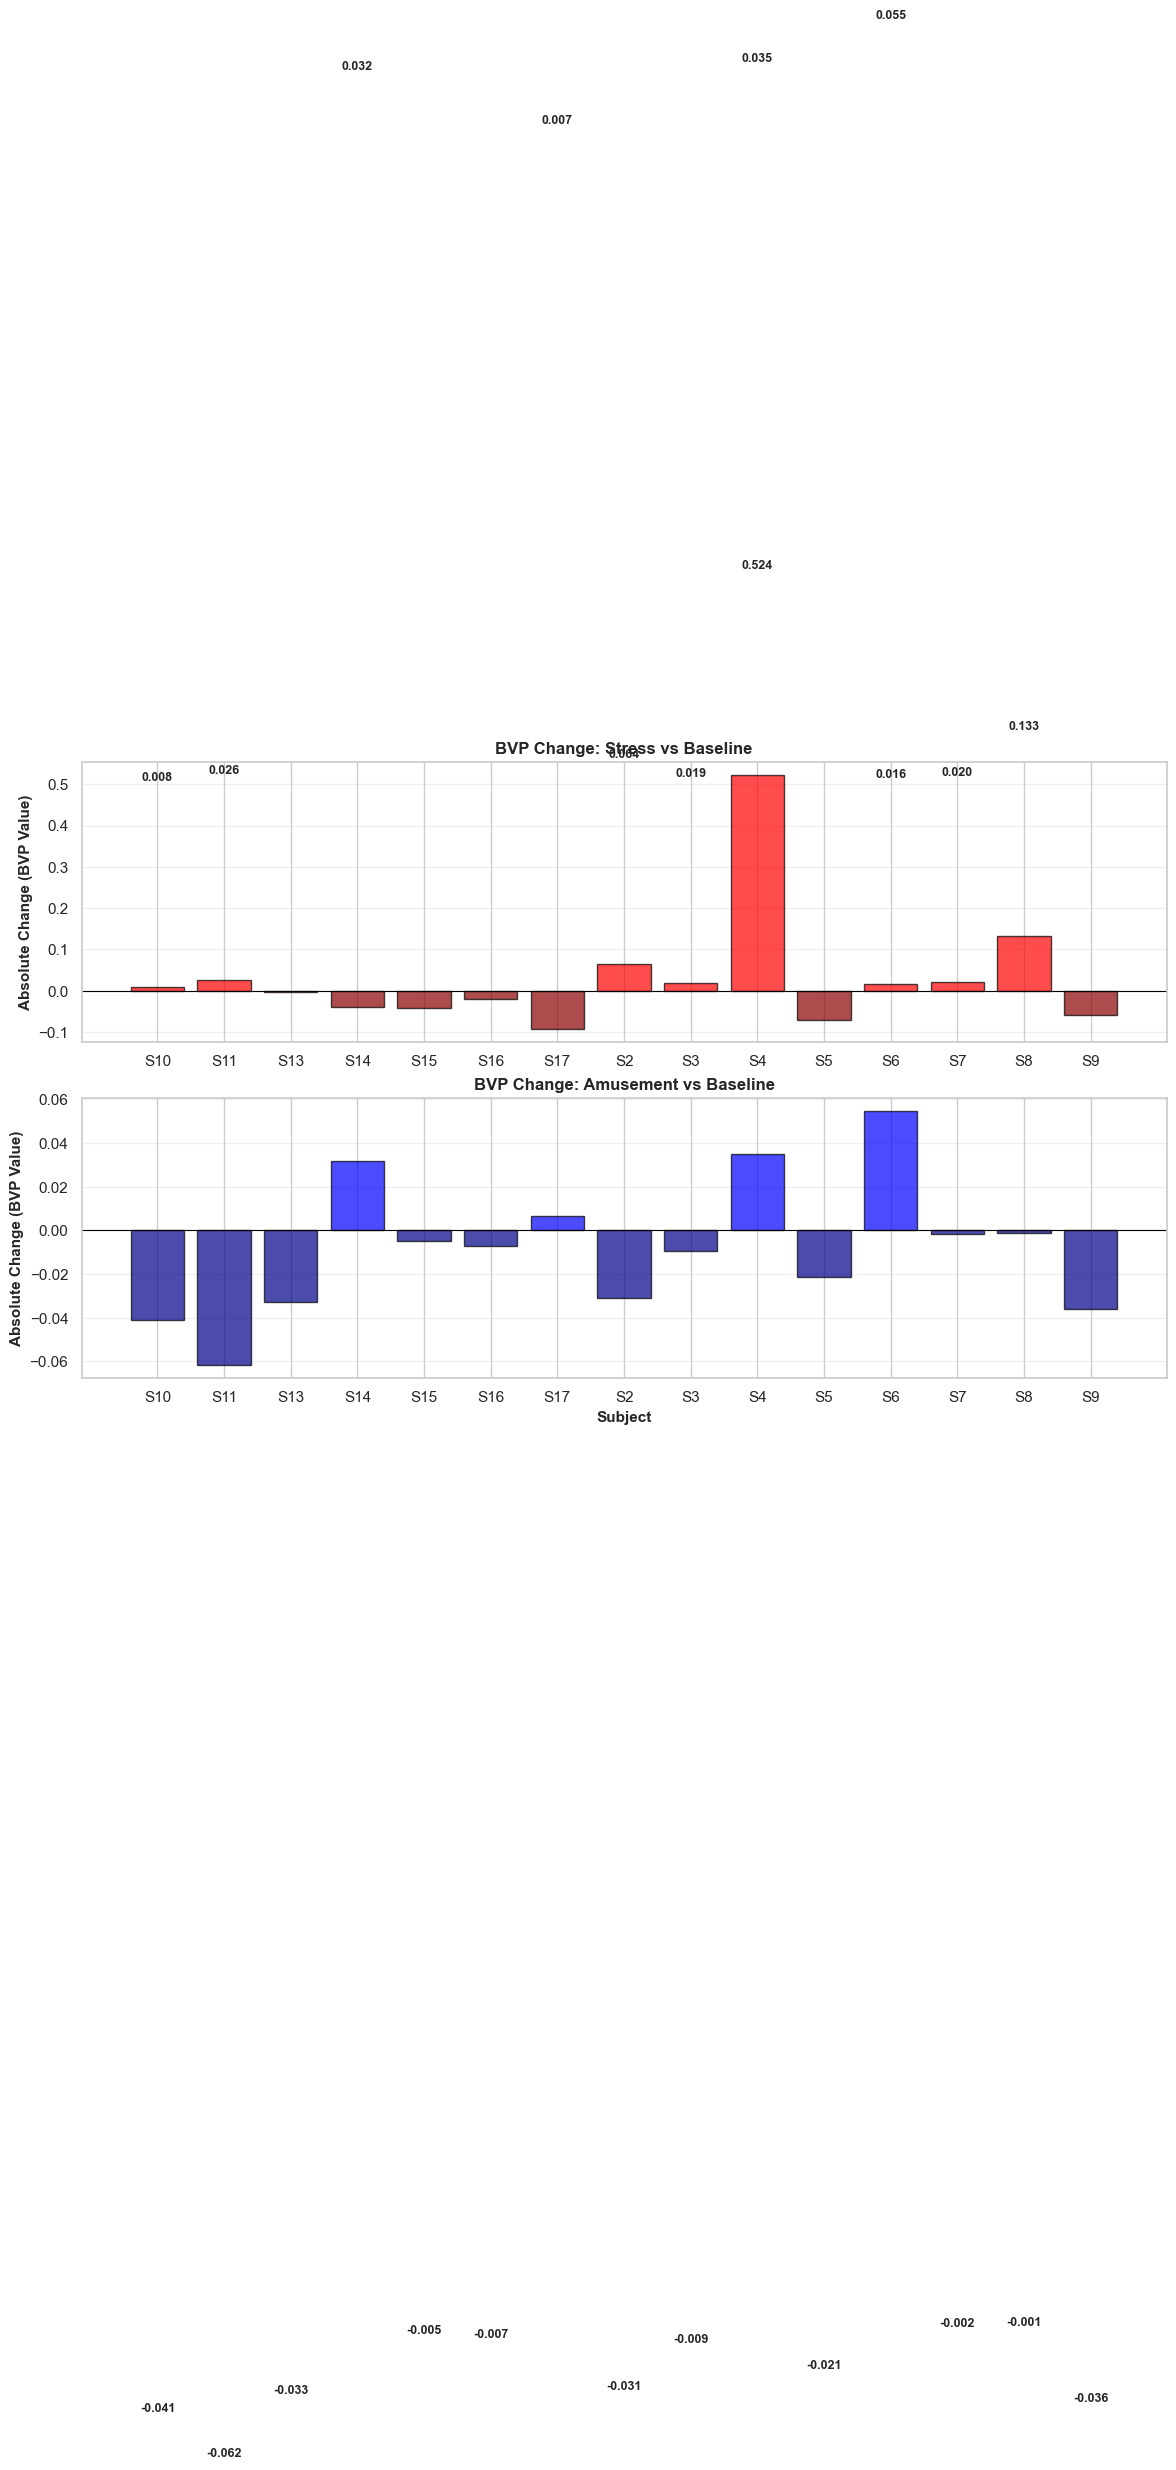


✓ BVP 절대 변화량 Bar Graph 생성 완료

📊 통계 요약 (절대 변화량):
  Stress 변화: +0.0322 (평균) | 범위: -0.0931 ~ 0.5235
  Amusement 변화: -0.0080 (평균) | 범위: -0.0617 ~ 0.0548

💡 해석:
  - 양수(+): Baseline 대비 증가
  - 음수(-): Baseline 대비 감소


In [20]:
# Subject별 상태 변화 시각화 (Bar Graph) - 절대 변화량
change_data = []

for subject_id in sorted(bvp_stats_df["subject"].unique()):
    subject_data = bvp_stats_df[bvp_stats_df["subject"] == subject_id]
    
    baseline_val = subject_data[subject_data["state"] == "Baseline"]["bvp_mean"].values
    stress_val = subject_data[subject_data["state"] == "Stress"]["bvp_mean"].values
    amusement_val = subject_data[subject_data["state"] == "Amusement"]["bvp_mean"].values
    
    baseline = baseline_val[0] if len(baseline_val) > 0 else np.nan
    stress = stress_val[0] if len(stress_val) > 0 else np.nan
    amusement = amusement_val[0] if len(amusement_val) > 0 else np.nan
    
    if not np.isnan(baseline):
        # 절대 변화량 (percentage 대신 absolute difference)
        stress_change = (stress - baseline) if not np.isnan(stress) else np.nan
        amusement_change = (amusement - baseline) if not np.isnan(amusement) else np.nan
        
        change_data.append({
            "subject": subject_id,
            "stress_change": stress_change,
            "amusement_change": amusement_change,
        })

change_df = pd.DataFrame(change_data)

# Figure: 2개 subplot으로 변화량 시각화
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# 1) Stress 변화량 (Baseline 대비 절대값)
ax1 = axes[0]
colors_stress = ["red" if x > 0 else "darkred" for x in change_df["stress_change"]]
bars1 = ax1.bar(change_df["subject"], change_df["stress_change"], color=colors_stress, alpha=0.7, edgecolor="black", linewidth=1)
ax1.axhline(y=0, color="black", linestyle="-", linewidth=0.8)
ax1.set_ylabel("Absolute Change (BVP Value)", fontsize=11, fontweight="bold")
ax1.set_title("BVP Change: Stress vs Baseline", fontsize=12, fontweight="bold")
ax1.grid(True, alpha=0.3, axis="y")

# 값 표시
for i, (subj, val) in enumerate(zip(change_df["subject"], change_df["stress_change"])):
    ax1.text(i, val + (0.5 if val > 0 else -0.5), f"{val:.3f}", ha="center", fontsize=9, fontweight="bold")

# 2) Amusement 변화량 (Baseline 대비 절대값)
ax2 = axes[1]
colors_amusement = ["blue" if x > 0 else "darkblue" for x in change_df["amusement_change"]]
bars2 = ax2.bar(change_df["subject"], change_df["amusement_change"], color=colors_amusement, alpha=0.7, edgecolor="black", linewidth=1)
ax2.axhline(y=0, color="black", linestyle="-", linewidth=0.8)
ax2.set_xlabel("Subject", fontsize=11, fontweight="bold")
ax2.set_ylabel("Absolute Change (BVP Value)", fontsize=11, fontweight="bold")
ax2.set_title("BVP Change: Amusement vs Baseline", fontsize=12, fontweight="bold")
ax2.grid(True, alpha=0.3, axis="y")

# 값 표시
for i, (subj, val) in enumerate(zip(change_df["subject"], change_df["amusement_change"])):
    ax2.text(i, val + (0.5 if val > 0 else -0.5), f"{val:.3f}", ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()

print("\n✓ BVP 절대 변화량 Bar Graph 생성 완료")
print(f"\n📊 통계 요약 (절대 변화량):")
print(f"  Stress 변화: {change_df['stress_change'].mean():+.4f} (평균) | 범위: {change_df['stress_change'].min():.4f} ~ {change_df['stress_change'].max():.4f}")
print(f"  Amusement 변화: {change_df['amusement_change'].mean():+.4f} (평균) | 범위: {change_df['amusement_change'].min():.4f} ~ {change_df['amusement_change'].max():.4f}")
print(f"\n💡 해석:")
print(f"  - 양수(+): Baseline 대비 증가")
print(f"  - 음수(-): Baseline 대비 감소")